# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [20]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
    #sets up the suit and rank when a new Card is created.    
    def get_value(self):
        if self.rank in ['J', 'Q', 'K']: return 10
        if self.rank == 'A': return 11
        return int(self.rank)
        
    def get_count_value(self):
        if self.rank in ['2', '3', '4', '5', '6']: return 1
        elif self.rank in ['7', '8', '9']: return 0
        else: return -1 # 10, J, Q, K, A
      # Returns the standard Blackjack numeric value of the card.  
    def __str__(self):
        return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = [] #main list that will hold all Card objects
        self.needs_shuffle = False
        self.build()
        #Automatically populates the deck when the object is created
        
    def build(self):
        self.cards = []
        self.needs_shuffle = False
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
        
        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))
              #For every deck, iterates through all 4 suits, and all 13 ranks.      
        self.shuffle()
        insert_idx = int(len(self.cards) * 0.75)
        self.cards.insert(insert_idx, "PLASTIC") #Plastic card is a string named in all caps to create a distinction between normal cards like 'Hearts', 'Diamonds', etc.
        #Plastic card enters the index of the other cards 75% of the way through the game's shuffling. 
        
    def shuffle(self):
        random.shuffle(self.cards)
        
    def draw(self):
        if len(self.cards) == 0:
            self.build()
            #if the deck empties completely, this functions rebuilds it.
            
        card = self.cards.pop(0) #removes and returns the top card from the list.
        if card == "PLASTIC":
            self.needs_shuffle = True #Toggle the flag so the game knows to shuffle next round
            card = self.cards.pop(0) # Draw the actual next card
        return card

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [32]:
class Player:
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = []
        self.bet = 0
        self.active = True #Boolean flag to check if they have enough money to play
#Player class start with an empty list or a deck with no cards yet, with an inital bet of 0.
    def clear_hand(self):
        self.hand = []
        self.active = True
        
    def get_hand_total(self): #Calculates the numeric value of the cards in the hand
        total = sum(card.get_value() for card in self.hand)
        aces = sum(1 for card in self.hand if card.rank == 'A')
        # If player busts but have an Ace, counts the Ace as 1 instead of 11
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total
#Since Aces are 11 or 1, if player busts and has an Ace, subtracts 10 from the Ace to treat it as a 1.
    def play_turn(self, deck, game_count=0):
        pass # Placeholder for the subclasses to override

class DealerPlayer(Player):
    def play_turn(self, deck, game_count=0):
        # Dealer rules: hit on 16, stand on 17
        while self.get_hand_total() < 17:
            self.hand.append(deck.draw())   #DealerPlayer inherits from Player, but implemented a play_turn method just for the dealer.

class Game:
    def __init__(self, players, num_decks=6): #Incorporates a deck object and stores list of player objects
        self.deck = Deck(num_decks)
        self.players = players
        self.dealer = DealerPlayer("Dealer")
        self.running_count = 0
        
    def play_round(self, verbose=True): #Checks boolean flag on the deck, if the plastic card was drawn, resets deck.
        if self.deck.needs_shuffle:
            if verbose: print("Plastic Card Hit: Shuffling Deck")
            self.deck.build()
            self.running_count = 0 #Tracks card counting integer for counters
            
        #Taking bets
        for p in self.players:
            p.clear_hand()
            if p.chips >= 10: 
                p.bet = 10
                p.chips -= 10 #Minimum bet is 10, when player bets takes away 10, if chips reduced all the way they are out of chips.
            else:
                p.active = False # Player is out of chips.
                
        self.dealer.clear_hand()
        
        #Deal 2 initial cards to everyone by looping twice
        for _ in range(2):
            for p in self.players:
                if p.active:
                    card = self.deck.draw()
                    p.hand.append(card) 
                    self.running_count += card.get_count_value() #Updates global count value state based on draw card
            
            #Dealer gets cards too and updates count
            dealer_card = self.deck.draw()
            self.dealer.hand.append(dealer_card)
            self.running_count += dealer_card.get_count_value()
            
        #Players take their turns
        for p in self.players:
            if p.active: #Triggers the specific play_turn logic for the subclass this player is
                p.play_turn(self.deck, self.running_count)
                # Count any new cards the player drew
                for card in p.hand[2:]: 
                    self.running_count += card.get_count_value()
                    
        #Dealer takes their turn
        self.dealer.play_turn(self.deck, self.running_count)
        for card in self.dealer.hand[2:]: #Slicing the list to only look at newly drawn cards
            self.running_count += card.get_count_value()
            
        #Determines winners and pays them out
        dealer_total = self.dealer.get_hand_total()
        for p in self.players:
            if not p.active: continue #Skip if they didn't play this round
            
            p_total = p.get_hand_total()
            if p_total > 21:
                pass #Bust, bet is lost
            elif dealer_total > 21 or p_total > dealer_total:
                p.chips += p.bet * 2 #Win, get bet back original bet + 1x profit
            elif p_total == dealer_total:
                p.chips += p.bet # Push, get bet back original bet and no profit

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [36]:
test_players = [
    DealerPlayer("Bot 1"), 
    DealerPlayer("Bot 2"), 
    DealerPlayer("Bot 3"),
    DealerPlayer("Bot 4"), 
    DealerPlayer("Bot 5"), 
    DealerPlayer("Bot 6"),
    DealerPlayer("Bot 7")
]

test_game = Game(test_players)

print("Testing Gameplay:")
for round_num in range(1, 8): #For all of the rounds, the function plays each one out.
    print(f"\nRound {round_num}")
    test_game.play_round(verbose=True)
    
    # Print out everyone's chips to show the game is working
    for p in test_players:
        print(f"{p.name} chip count: {p.chips}")

Testing Gameplay:

Round 1
Bot 1 chip count: 1010
Bot 2 chip count: 1010
Bot 3 chip count: 1010
Bot 4 chip count: 1010
Bot 5 chip count: 1010
Bot 6 chip count: 990
Bot 7 chip count: 990

Round 2
Bot 1 chip count: 1000
Bot 2 chip count: 1000
Bot 3 chip count: 1000
Bot 4 chip count: 1000
Bot 5 chip count: 1000
Bot 6 chip count: 980
Bot 7 chip count: 980

Round 3
Bot 1 chip count: 990
Bot 2 chip count: 990
Bot 3 chip count: 1000
Bot 4 chip count: 1000
Bot 5 chip count: 990
Bot 6 chip count: 970
Bot 7 chip count: 970

Round 4
Bot 1 chip count: 1000
Bot 2 chip count: 980
Bot 3 chip count: 1010
Bot 4 chip count: 990
Bot 5 chip count: 980
Bot 6 chip count: 980
Bot 7 chip count: 960

Round 5
Bot 1 chip count: 1010
Bot 2 chip count: 990
Bot 3 chip count: 1000
Bot 4 chip count: 980
Bot 5 chip count: 990
Bot 6 chip count: 990
Bot 7 chip count: 970

Round 6
Bot 1 chip count: 1000
Bot 2 chip count: 980
Bot 3 chip count: 990
Bot 4 chip count: 970
Bot 5 chip count: 990
Bot 6 chip count: 980
Bot 7 chi

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [37]:
class CounterPlayer(Player):
    def __init__(self, name, chips=1000, threshold=-2):
        super().__init__(name, chips)
        self.threshold = threshold
       #Subclassing Player to create our automatic card counter 
    def play_turn(self, deck, game_count=0):
        while True: #init is overrided because new attribute threshold is added.
            total = self.get_hand_total()
            
            # If we hit 21 or bust, function stops
            if total >= 21: 
                break
            
            
            # If the count is less than threshold, the deck has lower value cards.
            #It is safe to hit even if deck has a higher number.
            if game_count < self.threshold and total < 17:
                self.hand.append(deck.draw())
            #Function always hits on 12 since you physically can't bust.
            elif total < 12: 
                self.hand.append(deck.draw())
            else:
                break # Stay if neither condition is met

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [44]:
#Setup the players
strategy_player = CounterPlayer("Card Counter", chips=1000, threshold=-2)

#The prompt asks for 3 other players that follow the dealer's strategy
regular_players = [
    DealerPlayer("Regular 1", chips=1000),
    DealerPlayer("Regular 2", chips=1000),
    DealerPlayer("Regular 3", chips=1000)
]

#Combines them into one list and create the game by passing them all into the game constructor
all_players = [strategy_player] + regular_players
sim_game = Game(all_players)

#Plays 50 rounds
rounds_played = 0
for _ in range(50):
    #Stops early if counter goes broke
    if not strategy_player.active:
        break
        
    sim_game.play_round(verbose=False) #Keeps output quiet
    rounds_played += 1


#Winnings = Current Chips-Starting Chips
winnings = strategy_player.chips - 1000

print(f"Simulation Finished after {rounds_played} rounds.")
print(f"Card Counter's final chip count: {strategy_player.chips}")
print(f"Card Counter's net winnings: {winnings}")

Simulation Finished after 50 rounds.
Card Counter's final chip count: 970
Card Counter's net winnings: -30


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Avg Winnings per 50 rounds: -50.5
Standard Deviation: 80.24
Probability of Winning: 25.0%


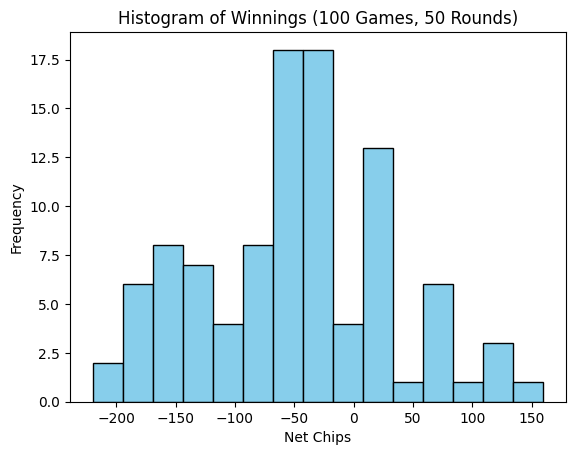

In [45]:
def run_simulation(threshold, num_games=100, rounds=50):
    winnings_list = [] #simulation in a function so it can easily run it multiple times with different settings
    #list stores the net profit/loss for the counter at the end of every 50 round game
    for _ in range(num_games):
        p1 = CounterPlayer("Counter", chips=1000, threshold=threshold)
        others = [HumanPlayer(f"Reg {i}", chips=1000) for i in range(3)]
        g = Game([p1] + others) #Runs 100 distinct games, resetting the players sery new game, and creates a new game instance.
        
        for _ in range(rounds): #Plays 50 rounds for current game
            if not p1.active: break
            g.play_round(verbose=False)
            
        winnings_list.append(p1.chips - 1000)
        
    return winnings_list #New winnings appended to the empty list 

results = run_simulation(threshold=-2) #Executes the simulation using a threshold of -2

#Statistics
avg_win = np.mean(results)
std_dev = np.std(results)
prob_win = sum(1 for x in results if x > 0) / len(results)

print(f"Avg Winnings per 50 rounds: {avg_win}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Probability of Winning: {prob_win * 100:.1f}%")

# Histogram
plt.hist(results, bins=15, color='skyblue', edgecolor='black') #groups winnings into bins and plots how many number games fell into each bin.
plt.title('Histogram of Winnings (100 Games, 50 Rounds)')
plt.xlabel('Net Chips')
plt.ylabel('Frequency')
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Threshold -4 | Avg Winnings: -26.1
Threshold -2 | Avg Winnings: -42.2
Threshold  0 | Avg Winnings: -42.5
Threshold  2 | Avg Winnings: -25.2
Threshold  4 | Avg Winnings: -39.9


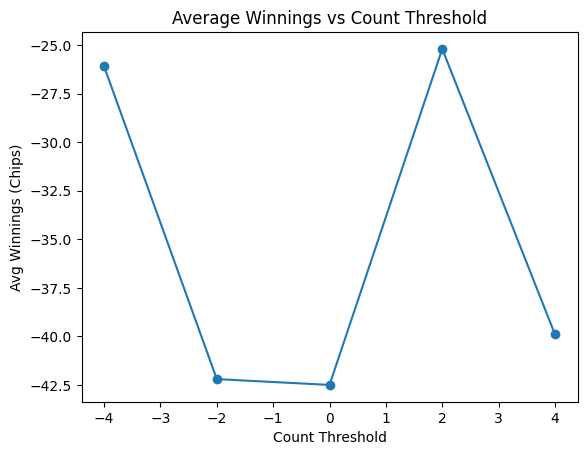

In [46]:
thresholds_to_test = [-4, -2, 0, 2, 4]
averages = []

for t in thresholds_to_test: #Loops through every thereshold value
    res = run_simulation(threshold=t, num_games=100) # Runs the 100 games for the current threshold
    averages.append(np.mean(res)) #Calculates and stores the mean
    print(f"Threshold {t:2d} | Avg Winnings: {np.mean(res)}")

plt.plot(thresholds_to_test, averages, marker='o', linestyle='-')
plt.title("Average Winnings vs Count Threshold")
plt.xlabel("Count Threshold")
plt.ylabel("Avg Winnings (Chips)")
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [51]:
# Inherits from base Player class
class DefaultStrategyPlayer(Player):
    def play_turn(self, deck, game_count=0):
        dealer_upcard = 10 #Hardcoded value for simplicity
        
        #Infinite loop for the player's turn decisions
        while True:
            total = self.get_hand_total()
            
            #Condition 1: If player has 17 or more, they always stop, or if they bust.
            if total >= 17: 
                break
            
            #Condition 2: Check if there is a hand that can bust
            # If player has a hand that can bust (from 12-16), ad the dealer is showing a weak card, player stands to see if the dealer busts.
            if total >= 12 and dealer_upcard in [4, 5, 6]:
                break # Stand
                
            # Condition 3: Default play
            # If the dealer has a strong card, player will hit to try to catch up to them even if it means they bust.
            else:
                self.hand.append(deck.draw())


print("Testing Player Strategy")

basic_winnings = []

#Run our standard 100-game Monte Carlo simulation
for _ in range(100):
    # Incorporate the new Basic Strategy player
    p1 = BasicStrategyPlayer("Basic Strategist", chips=1000)
    
    #Fill the rest of the table with regular dealer bots
    others = [DealerPlayer(f"Reg {i}", chips=1000) for i in range(3)]
    
    #Create the game instance
    g = Game([p1] + others)
    
    #Play 50 rounds
    for _ in range(50):
        if not p1.active: 
            break # Stop if the player goes broke
        g.play_round(verbose=False)
        
    #Record the net profit/loss
    basic_winnings.append(p1.chips - 1000)


basic_avg = np.mean(basic_winnings)
basic_prob = sum(1 for x in basic_winnings if x > 0) / len(basic_winnings)

print(f"Basic Strategy Avg Winnings (50 rounds): {basic_avg:.2f} chips")
print(f"Basic Strategy Win Probability: {basic_prob * 100:.1f}%") #Losses are decreased, even though player mostly loser, so it is better than the bot dealer and step 6 strategy with around a 20 win rate.

Testing Player Strategy
Basic Strategy Avg Winnings (50 rounds): -40.80 chips
Basic Strategy Win Probability: 26.0%
